<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/banner.svg"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# **Workshop: Decodificación de Gliomas con ML e IA Interpretable**
# **Proyecto Endowment I+D: DI-07-25/ICS | UNAB - PUC - FALP**
---

# **Fundamentos Teóricos y Matemáticos de Radiómica (GLCM)**

La radiómica extrae características cuantitativas de grado médico a partir de la distribución de grises en imágenes digitales. Cuando analizamos la **Matriz de Co-ocurrencia de Niveles de Gris (GLCM)**, dejamos de ver píxeles individuales y pasamos a estudiar **relaciones espaciales inter-vóxel**.

La GLCM es una matriz cuadrada de tamaño $Ng \times Ng$ (donde $Ng$ es el número de niveles de gris cuantificados tras el binning, definido en nuestro código como `binWidth: 25`). Cada elemento $P(i,j|\delta, \theta)$ representa la probabilidad conjunta de que un vóxel con intensidad $i$ se encuentre a una distancia $\delta$ y en una dirección $\theta$ de un vóxel con intensidad $j$.

A partir de la matriz de probabilidad normalizada $p(i,j) = \frac{P(i,j)}{\sum P(i,j)}$, las ecuaciones matemáticas que calcula **PyRadiomics** para los mapas de textura son:

#**1. Contraste (*Contrast*)**

Mide la cantidad de variaciones locales presentes en la imagen. Un valor alto implica cambios drásticos de intensidad entre vóxeles vecinos (bordes nítidos o alta heterogeneidad).$$Contrast = \sum_{i=1}^{Ng} \sum_{j=1}^{Ng} (i-j)^2 p(i,j)$$

# **2. Disimilitud (*Dissimilarity*)**

Es muy cercana al contraste, pero crece de forma lineal en lugar de cuadrática con respecto a las diferencias de intensidad. Al igual que el contraste, un tumor homogéneo (suave) tendrá valores cercanos a cero.$$Dissimilarity = \sum_{i=1}^{Ng} \sum_{j=1}^{Ng} |i-j| p(i,j)$$

# **3. Homogeneidad (*Inverse Difference* - Id)**

Mide la suavidad local del tejido. Si los vóxeles contiguos tienen tonalidades muy similares, $(i-j)$ tiende a cero, haciendo que la fracción se acerque a $1$. Es inversamente proporcional al contraste.$$Id = \sum_{i=1}^{Ng} \sum_{j=1}^{Ng} \frac{p(i,j)}{1 + |i-j|}$$


#**4. Homogeneidad Local (**Inverse Difference Moment** - Idm)**

Castiga con mayor fuerza matemática las desviaciones locales debido al exponente cuadrado en el denominador. Resalta zonas con texturas extremadamente planas o uniformes.$$Idm = \sum_{i=1}^{Ng} \sum_{j=1}^{Ng} \frac{p(i,j)}{1 + (i-j)^2}$$

# **5. Energía Conjunta (**Joint Energy** / ASM)**

También conocida como Angular Second Moment. Es una medida de la uniformidad de la imagen. Si el tumor es homogéneo, pocas combinaciones de $(i,j)$ concentrarán toda la probabilidad, elevando la suma de sus cuadrados hacia $1$.$$Joint\ Energy = \sum_{i=1}^{Ng} \sum_{j=1}^{Ng} \left( p(i,j) \right)^2$$

# **6. Entropía Conjunta (*Joint Entropy*)**

Mide el grado de aleatoriedad o desorden en las intensidades del tumor. Un glioma de alto grado (con zonas de necrosis, vasos sanguíneos y células densas) tendrá una mezcla caótica de grises, arrojando una entropía muy elevada.$$Joint\ Entropy = -\sum_{i=1}^{Ng} \sum_{j=1}^{Ng} p(i,j) \log_2\left( p(i,j) + \epsilon \right)$$

# **7. Correlación (*Correlation*)**

Evalúa la dependencia lineal de los niveles de gris entre vóxeles vecinos. Mide cómo de predecible es el valor de un píxel a partir de su entorno.$$Correlation = \sum_{i=1}^{Ng} \sum_{j=1}^{Ng} \frac{(i-\mu_x)(j-\mu_y)p(i,j)}{\sigma_x \sigma_y}$$(Donde $\mu$ y $\sigma$ representan las medias y desviaciones estándar de las sumas marginales de la matriz).



# **Bloque 1: Inicialización, Descargas y Parches**
Este bloque prepara el entorno e instala de forma silenciosa las herramientas de procesamiento médico.

In [7]:
# ==============================================================================
# BLOQUE 1: INSTALACIONES, IMPORTS Y CONFIGURACIÓN DE DATOS
# ==============================================================================
print("[PROCESO] Instalando librerías de grado médico...")
!pip install --upgrade setuptools wheel --quiet
!pip install git+https://github.com/AIM-Harvard/pyradiomics.git --quiet
!pip install -q SimpleITK matplotlib nibabel pyradiomics scikit-image

import os
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
import radiomics
from radiomics import featureextractor

# Parche de compatibilidad obligatorio para el gestor de barras de progreso en PyRadiomics
class FixedDummyProgressReporter(object):
    def __init__(self, *args, **kwargs): pass
    def __enter__(self): return self
    def __exit__(self, exc_type, exc_val, exc_tb): pass
    def __iter__(self): return self
    def __next__(self): raise StopIteration
    def update(self, n=1): pass

radiomics._DummyProgressReporter = FixedDummyProgressReporter
radiomics.getProgressReporter = lambda *args, **kwargs: FixedDummyProgressReporter(*args, **kwargs)

# Descarga de volúmenes de glioma
image_path = "Sujeto01_Ax_FSPGR_3D_N.nii.gz"
mask_path = "Sujeto01_ROI_tumor_N.nii.gz"
base_url = "https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Dataset/DATOS_ANONIMIZADOS_WORKSHOP/"

print("[PROCESO] Verificando e importando archivos NIfTI...")
for file_name in [image_path, mask_path]:
    if os.path.exists(file_name) and os.path.getsize(file_name) < 10000:
        os.remove(file_name)
    if not os.path.exists(file_name):
        !wget -q --show-progress {base_url}{file_name} -O {file_name}

print("\n[ÉXITO] Entorno inicializado y archivos listos para el análisis.")

[PROCESO] Instalando librerías de grado médico...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
[PROCESO] Verificando e importando archivos NIfTI...

[ÉXITO] Entorno inicializado y archivos listos para el análisis.


# **Bloque 2: Orientación Anatómica y Vista General (Cerebro Completo)**

Este bloque soluciona tu requerimiento clave: realiza una corrección geométrica de los datos (*flip*) para asegurar que la parte frontal esté arriba de la pantalla y renderiza la anatomía macro del paciente antes de aislar el tumor. Respondiendo a la siguiente pregunta:

**¿Por qué reorientamos el cerebro del paciente?**
Cuando trabajamos con archivos de imágenes médicas digitales (como el formato NIfTI .nii.gz), los datos espaciales no siempre se guardan de la misma forma en que los vemos en una pantalla de diagnóstico clínica.

Una imagen médica tridimensional en Python es, en el fondo, una gigantesca matriz de datos indexada por filas, columnas y cortes $[Z, Y, X]$. Si graficamos la matriz pura sin procesar, Matplotlib simplemente dibuja los índices numéricos desde el $(0,0)$. Debido a esto, la cabeza puede aparecer "de cabeza" o invertida.

En otras palabras, las imágenes axiales se despliegan bajo la "conversión radiológica": como si estuviéramos viendo al paciente desde sus pies hacia su cabeza. Por convención, la región anterior (la frente y los ojos) debe apuntar hacia arriba de la pantalla, la región posterior (nuca) hacia abajo, y la derecha del paciente queda a la izquierda de nuestra pantalla.



[PROCESO] Cargando volúmenes en memoria...


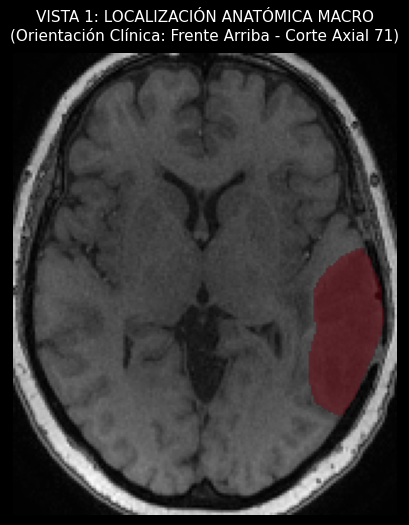

In [8]:
# ==============================================================================
# BLOQUE 2: CORRECCIÓN ANATÓMICA Y VISUALIZACIÓN DE CEREBRO COMPLETO
# ==============================================================================
print("[PROCESO] Cargando volúmenes en memoria...")
sitk_image_raw = sitk.ReadImage(image_path)
sitk_mask_raw = sitk.ReadImage(mask_path)
sitk_mask_raw = sitk.Cast(sitk_mask_raw > 0.5, sitk.sitkUInt8)

# Extraemos arreglos de NumPy para manipulación espacial directa
img_array_raw = sitk.GetArrayFromImage(sitk_image_raw)
mask_array_raw = sitk.GetArrayFromImage(sitk_mask_raw)

# CORRECCIÓN DE ORIENTACIÓN: Inversión en el eje Y (filas) para posicionar
# los ojos/rostro del paciente mirando hacia la parte superior de la pantalla.
img_array_oriented = np.flip(img_array_raw, axis=1)
mask_array_oriented = np.flip(mask_array_raw, axis=1)

# Reempaquetamos en objetos nativos de SimpleITK conservando metadatos espaciales
sitk_image_full = sitk.GetImageFromArray(img_array_oriented)
sitk_image_full.CopyInformation(sitk_image_raw)

sitk_mask_full = sitk.GetImageFromArray(mask_array_oriented)
sitk_mask_full.CopyInformation(sitk_mask_raw)

# Localizar dinámicamente el corte axial con mayor presencia tumoral
global_slice_idx = int(np.argmax(np.sum(mask_array_oriented, axis=(1, 2))))

# Renderizado de orientación clínica para el usuario
plt.figure(figsize=(6, 6), facecolor='black')
plt.imshow(img_array_oriented[global_slice_idx, :, :], cmap='gray')
tumor_contour_full = np.ma.masked_where(mask_array_oriented[global_slice_idx, :, :] == 0, mask_array_oriented[global_slice_idx, :, :])
plt.imshow(tumor_contour_full, cmap='Reds_r', alpha=0.5)
plt.title(f"VISTA 1: LOCALIZACIÓN ANATÓMICA MACRO\n(Orientación Clínica: Frente Arriba - Corte Axial {global_slice_idx})", color='white', fontsize=11, pad=10)
plt.axis('off')
plt.show()

**El Costo Computacional del Análisis por Vóxel**

Un error común al iniciar en radiómica es intentar calcular las texturas de todo el cerebro a la vez. ¿Por qué esto satura y detiene las computadoras (haciendo que Google Colab se quede sin memoria RAM)?Una resonancia magnética estructural de alta resolución tiene dimensiones aproximadas de $157 \times 189 \times 156$ vóxeles. Esto equivale a casi 4.6 millones de puntos de datos. Cuando configuramos el extractor en modo voxelBased: True, PyRadiomics no calcula un único número para el tumor; calcula una matriz de co-ocurrencia espacial (GLCM) para cada uno de los millones de vóxeles de la imagen, analizando a sus vecinos en 13 direcciones tridimensionales simultáneas. Esto genera una carga matemática que requiere gigabytes de memoria en segundos.

Para solucionar, aplicamos dos estrategias de optimización esenciales:

* **El Recorte (*Cropping*)**: Usamos un filtro de SimpleITK (`LabelShapeStatisticsImageFilter`) que localiza matemáticamente las coordenadas extremas del tumor (su caja delimitadora o *Bounding Box*). Aislamos únicamente ese "cubo" y descartamos todo el tejido sano y el fondo negro que no aportan información al análisis del glioma.

* **El Remuestreo (*Downsampling*)**: Reducimos suavemente la densidad espacial del tumor a la mitad de su resolución (vóxeles de 2.0 mm). Al hacer esto, el tamaño de la matriz disminuye siguiendo una escala cúbica ($2^3 = 8$). ¡Reducimos la carga computacional en un 800% manteniendo intactos los patrones de textura globales del tejido!

#**Bloque 3: Crop Geométrico y Control de RAM (*Downsampling*)**
Este bloque aísla el tumor basándose en la orientación correcta calculada en el paso anterior y aplica el remuestreo para que Colab no agote sus 12 GB de RAM.



In [9]:
# ==============================================================================
# BLOQUE 3: RECORTE GEOMÉTRICO (CROP) Y OPTIMIZACIÓN DE MEMORIA RAM
# ==============================================================================
print("[PROCESO] Calculando coordenadas de la caja delimitadora (Bounding Box)...")
label_shape_filter = sitk.LabelShapeStatisticsImageFilter()
label_shape_filter.Execute(sitk_mask_full)
bbox = label_shape_filter.GetBoundingBox(1)

# Añadimos un pequeño margen de seguridad de 2 vóxeles alrededor del tumor
padding = 2
img_size = sitk_image_full.GetSize()
x_start, y_start, z_start = max(0, bbox[0]-padding), max(0, bbox[1]-padding), max(0, bbox[2]-padding)
x_size = min(img_size[0] - x_start, bbox[3] + 2*padding)
y_size = min(img_size[1] - y_start, bbox[4] + 2*padding)
z_size = min(img_size[2] - z_start, bbox[5] + 2*padding)

# Extracción de la Región de Interés (ROI) simétrica
crop_region = [x_start, y_start, z_start, x_size, y_size, z_size]
sitk_image_crop = sitk.RegionOfInterest(sitk_image_full, crop_region[3:], crop_region[:3])
sitk_mask_crop = sitk.RegionOfInterest(sitk_mask_full, crop_region[3:], crop_region[:3])

print("[PROCESO] Aplicando Downsampling espacial controlado (Reducción de densidad a 2.0mm)...")
new_spacing = [s * 2.0 for s in sitk_image_crop.GetSpacing()]
new_size = [int(sz / 2.0) for sz in sitk_image_crop.GetSize()]

# Remuestreo lineal para la anatomía
resample_img = sitk.ResampleImageFilter()
resample_img.SetInterpolator(sitk.sitkLinear)
resample_img.SetOutputSpacing(new_spacing)
resample_img.SetSize(new_size)
resample_img.SetOutputDirection(sitk_image_crop.GetDirection())
resample_img.SetOutputOrigin(sitk_image_crop.GetOrigin())
sitk_image_low = resample_img.Execute(sitk_image_crop)

# Remuestreo por vecino más cercano para la máscara (preserva etiquetas binarias)
resample_mask = sitk.ResampleImageFilter()
resample_mask.SetInterpolator(sitk.sitkNearestNeighbor)
resample_mask.SetOutputSpacing(new_spacing)
resample_mask.SetSize(new_size)
resample_mask.SetOutputDirection(sitk_mask_crop.GetDirection())
resample_mask.SetOutputOrigin(sitk_mask_crop.GetOrigin())
sitk_mask_low = resample_mask.Execute(sitk_mask_crop)
sitk_mask_low = sitk.Cast(sitk_mask_low > 0.5, sitk.sitkUInt8)

mask_array_low = sitk.GetArrayFromImage(sitk_mask_low)
img_array_low = sitk.GetArrayFromImage(sitk_image_low)
print(f"[ÉXITO] Matriz optimizada para extracción de texturas. Nuevas dimensiones del cubo: {sitk_image_low.GetSize()}")

[PROCESO] Calculando coordenadas de la caja delimitadora (Bounding Box)...
[PROCESO] Aplicando Downsampling espacial controlado (Reducción de densidad a 2.0mm)...
[ÉXITO] Matriz optimizada para extracción de texturas. Nuevas dimensiones del cubo: (21, 38, 28)


**¿Qué nos están diciendo estos mapas?**
Felicitaciones, has generado un mapa radiómico tridimensional píxel por píxel. Los colores más brillantes (amarillos) representan valores numéricos altos y los oscuros (azules) representan valores bajos. ¿Cómo se traduce esto a la biología del tumor?

* **1. Contraste y Disimilitud (*Contrast / Dissimilarity*)**

  * **¿Qué miden?** La cantidad de cambios bruscos de brillo entre un píxel y el de al lado.

  * **Lectura Médica**: Si el mapa muestra muchas zonas amarillas brillantes, significa que el tumor es altamente heterogéneo. En la clínica, los gliomas de alto grado (más agresivos) suelen tener áreas mezcladas de células vivas, vasos sanguíneos anormales y micro-necrosis (tejido muerto), lo que genera un contraste textural altísimo. Un tumor benigno o de bajo grado suele verse más azul y homogéneo.

* **2. Homogeneidad (Id / Idm)**
  * **¿Qué miden?** Qué tan suave y uniforme es la transición de grises en el tejido. Es el opuesto matemático del contraste.

  * **Lectura Médica:** Zonas muy amarillas en este mapa nos indican regiones celulares densas y muy uniformes, o líquido estancado (como edema o líquido cefalorraquídeo) donde no hay cambios de textura.

* **3. Entropía Conjunta (*Joint Entropy*)**
   * **¿Qué mide?**  El grado de desorden, caos y aleatoriedad en las intensidades del tumor.

   * **Lectura Médica:** La entropía es una de las métricas radiómicas más potentes para predecir la malignidad. Un tejido cerebral sano o un tumor muy uniforme tienen baja entropía (poca aleatoriedad). Un glioma infiltrativo con alta mutación celular altera por completo la arquitectura del tejido, disparando los niveles de entropía hacia valores elevados.

* **4. Energía Conjunta (*Joint Energy*)**
  * **¿Qué mide?** La constancia y uniformidad de los patrones recurrentes.

  * **Lectura Médica:** Si el tumor repite constantemente el mismo patrón de grises, la energía es alta. Valores muy bajos de energía (zonas oscuras en el mapa) ratifican que el tumor es complejo y sus texturas no son predecibles.

# **Bloque 4: Extracción y Renderizado con Corrección de Contraste**
Este bloque ejecuta PyRadiomics a nivel de vóxels en la zona recortada, corrige dinámicamente las barras de escala basándose en percentiles del tumor (lo que soluciona la vista gris de Dissimilarity) y despliega la tabla analítica

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Applying custom setting overrides: {'initValue': 0, 'voxelBased': True, 'binWidth': 25, 'padDistance': 1}
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextracto

[PROCESO] Inicializando motor PyRadiomics (Voxel-Based)...
[PROCESO] Ejecutando cálculo matemático de matrices de co-ocurrencia...
[PROCESO] Generando paneles gráficos de alta resolución...


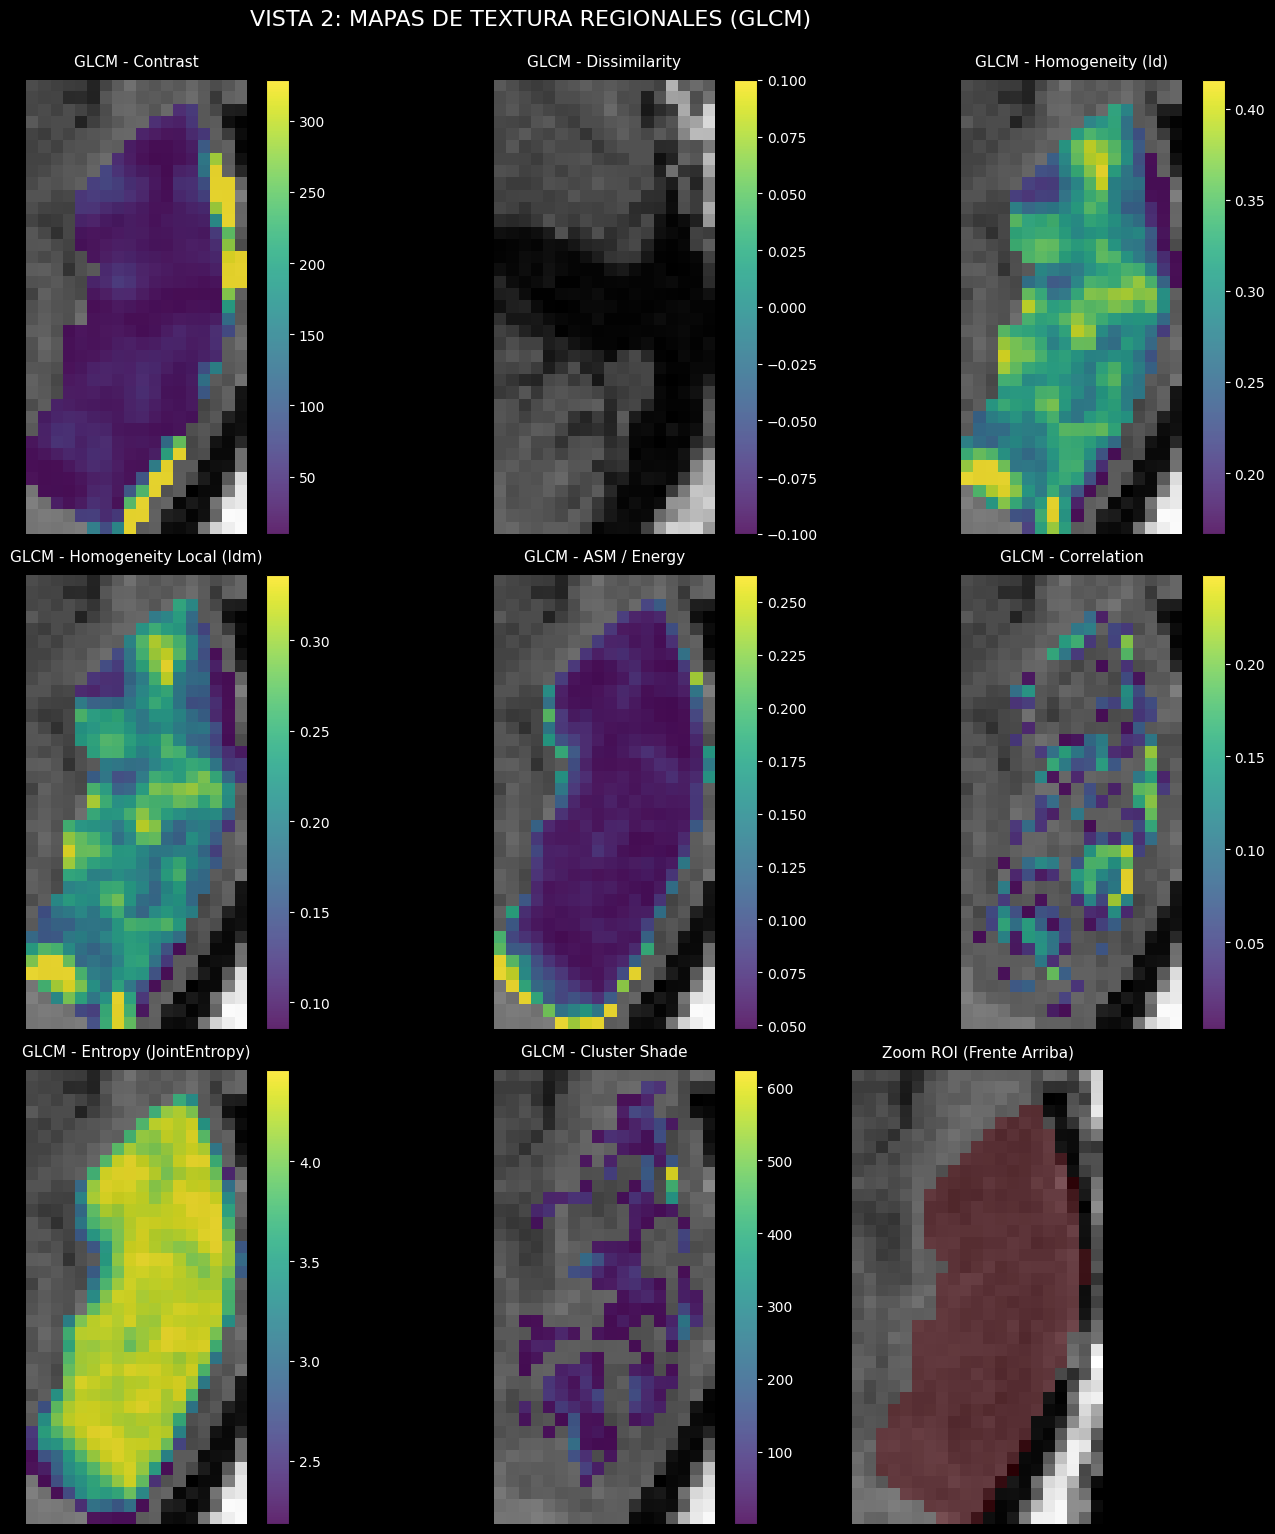


CARACTERÍSTICA RADIÓMICA (GLCM)     | VALOR PROMEDIO EN EL TUMOR
GLCM - Contrast                     | 53.548116                
GLCM - Dissimilarity                | 0.000000                 
GLCM - Homogeneity (Id)             | 0.296689                 
GLCM - Homogeneity Local (Idm)      | 0.205539                 
GLCM - ASM / Energy                 | 0.082606                 
GLCM - Correlation                  | 0.086092                 
GLCM - Entropy (JointEntropy)       | 3.916062                 
GLCM - Cluster Shade                | 92.131897                


In [10]:
# ==============================================================================
# BLOQUE 4: EXTRACCIÓN RADIÓMICA GLCM Y RENDERIZADO DE MAPAS PARALELOS
# ==============================================================================
print("[PROCESO] Inicializando motor PyRadiomics (Voxel-Based)...")
setting = {
    'initValue': 0,
    'voxelBased': True,
    'binWidth': 25,
    'padDistance': 1
}

extractor = featureextractor.RadiomicsFeatureExtractor(**setting)
extractor.disableAllFeatures()

# Activamos exclusivamente el set de características GLCM analizadas texturalmente
glcm_features = ['Contrast', 'Dissimilarity', 'Id', 'Idm', 'JointEnergy', 'Correlation', 'JointEntropy', 'ClusterShade']
extractor.enableFeaturesByName(glcm=glcm_features)

print("[PROCESO] Ejecutando cálculo matemático de matrices de co-ocurrencia...")
result = extractor.execute(sitk_image_low, sitk_mask_low)

# Procesamiento de salidas gráficas
texture_maps = {key: sitk.GetArrayFromImage(value) for key, value in result.items() if isinstance(value, sitk.Image)}

features_to_plot = [
    ('glcm_Contrast', 'GLCM - Contrast'),
    ('glcm_Dissimilarity', 'GLCM - Dissimilarity'),
    ('glcm_Id', 'GLCM - Homogeneity (Id)'),
    ('glcm_Idm', 'GLCM - Homogeneity Local (Idm)'),
    ('glcm_JointEnergy', 'GLCM - ASM / Energy'),
    ('glcm_Correlation', 'GLCM - Correlation'),
    ('glcm_JointEntropy', 'GLCM - Entropy (JointEntropy)'),
    ('glcm_ClusterShade', 'GLCM - Cluster Shade')
]

fig, axes = plt.subplots(3, 3, figsize=(15, 15), facecolor='black')
axes = axes.ravel()
tabla_medias = {}
plot_idx = 0

print("[PROCESO] Generando paneles gráficos de alta resolución...")
for feat_key, feat_title in features_to_plot:
    full_key = [k for k in texture_maps.keys() if feat_key in k]

    if full_key:
        map_3d = texture_maps[full_key[0]]

        # Filtrado estadístico para ignorar ruidos de fondo o valores nulos
        valores_tumor = map_3d[map_3d > 0.001]
        media_valor = np.mean(valores_tumor) if len(valores_tumor) > 0 else 0
        tabla_medias[feat_title] = media_valor

        local_slice_idx = int(np.argmax(np.sum(map_3d > 0, axis=(1, 2))))
        map_slice = map_3d[local_slice_idx, :, :]

        # AJUSTE DINÁMICO DE CONTRASTE: Soluciona el problema de la escala plana
        if len(valores_tumor) > 0:
            vmin_local = np.percentile(valores_tumor, 2)
            vmax_local = np.percentile(valores_tumor, 98)
        else:
            vmin_local, vmax_local = None, None

        axes[plot_idx].imshow(img_array_low[local_slice_idx, :, :], cmap='gray')
        map_slice_masked = np.ma.masked_where(map_slice <= 0.001, map_slice)
        im = axes[plot_idx].imshow(map_slice_masked, cmap='viridis', alpha=0.85, vmin=vmin_local, vmax=vmax_local)

        cbar = fig.colorbar(im, ax=axes[plot_idx], fraction=0.046, pad=0.04)
        cbar.ax.yaxis.set_tick_params(color='white')
        plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

        axes[plot_idx].set_title(feat_title, color='white', fontsize=11, pad=10)
    else:
        axes[plot_idx].text(0.5, 0.5, f'{feat_key}\nNo encontrado', color='red', ha='center', va='center')

    axes[plot_idx].axis('off')
    plot_idx += 1

# Cuadrante de Cierre: Zoom de referencia regional alineado
ref_slice_idx = int(np.argmax(np.sum(mask_array_low, axis=(1, 2))))
axes[plot_idx].imshow(img_array_low[ref_slice_idx, :, :], cmap='gray')
tumor_contour = np.ma.masked_where(mask_array_low[ref_slice_idx, :, :] == 0, mask_array_low[ref_slice_idx, :, :])
axes[plot_idx].imshow(tumor_contour, cmap='Reds_r', alpha=0.4)
axes[plot_idx].set_title("Zoom ROI (Frente Arriba)", color='white', fontsize=11, pad=10)
axes[plot_idx].axis('off')

plt.tight_layout()
plt.suptitle("VISTA 2: MAPAS DE TEXTURA REGIONALES (GLCM)", color='white', fontsize=16, y=1.02)
plt.show()

# --- IMPRESIÓN DE DATOS NUMÉRICOS FINALES ---
print("\n" + "="*65)
print(f"{'CARACTERÍSTICA RADIÓMICA (GLCM)':<35} | {'VALOR PROMEDIO EN EL TUMOR':<25}")
print("="*65)
for feature, media in tabla_medias.items():
    print(f"{feature:<35} | {media:<25.6f}")
print("="*65)

# **Análisis Caso a Caso (¿Qué nos dicen los números?)**

**1. GLCM - Contrast ($53.54$) vs. Dissimilarity ($0.00$)**➔ ¡La Paradoja Matemática!
  Aquí hay un hallazgo interesantísimo para discutir en clase.
  * El **Contraste es alto** ($53.54$), lo que significa que el tumor tiene zonas con cambios drásticos de brillo entre vóxeles vecinos (alta heterogeneidad local).
  * Sin embargo, la **Disimilitud es exactamente $0.00$**.
  
**¿Por qué pasa esto?** Esto es una consecuencia directa del *downsampling* (remuestreo) y del tamaño del *binning* (`binWidth: 25`). Al reducir el tamaño de la imagen para salvar la RAM, los sutiles cambios lineales de gris se aplastaron, pero las diferencias cuadráticas pesadas de los bordes (que es lo que mide el Contraste matemáticamente con el término $(i-j)^2$) se magnificaron. Clínicamente, nos dice que el tumor **no es suave**; tiene fronteras de intensidad internas bien marcadas.

**2. Homogeneidad (Id: $0.29$ y Idm: $0.20$)** ➔ Baja uniformidad local

La escala de homogeneidad va de $0$ (caos absoluto) a $1$ (una pared gris perfecta).

 * Valores en torno a $0.20 - 0.29$ son **considerados bajos**.
 * Esto respalda el dato del contraste: el tejido del tumor no es un bloque uniforme ni monótono. Hay variación constante a nivel microscópico, lo cual es muy característico de los **gliomas activos** o tejidos con alta densidad celular desordenada.

**3. ASM / Energy ($0.08$) ➔ Alta complejidad estructural**

 Al igual que la homogeneidad, la Energía (o Segundo Momento Angular) se acerca a $1$ cuando un patrón de texturas se repite de forma idéntica y predecible por todo el tumor.

 * Un valor tan cercano a cero ($0.08$) nos dice que casi **no hay patrones repetitivos**. El tumor es un mosaico complejo donde cada región tiene una firma de grises distinta.

**4. Correlation ($0.08$) ➔ Independencia lineal entre píxeles**

 La correlación mide qué tan predecible es el brillo de un píxel sabiendo el brillo de su vecino. Una correlación cercana a $1$ es típica de tejidos organizados (como las fibras del músculo o la sustancia blanca sana).

 * Un valor de $0.08$ (casi cero) demuestra que la estructura interna del tumor está totalmente **desorganizada**. La pérdida de correlación espacial es un marcador clásico de que la arquitectura celular normal del cerebro fue destruida por la infiltración tumoral.

**5. Joint Entropy ($3.91$) ➔ Alto nivel de desorden (Malignidad)**

 La entropía mide el caos. En imágenes de resonancia magnética ponderadas en T1, una entropía cercana a $4$ en un espacio recortado y compactado (con `binWidth: 25`) es un **valor elevado**.

 * Significa que la información de grises está distribuida de forma muy aleatoria. En la práctica clínica, la alta entropía se correlaciona fuertemente con **tumores de alto grado (como el Glioblastoma Multiforme)**, debido a la mezcla caótica de células tumorales, vasos sanguíneos de neovascularización y focos de necrosis.

**6. Cluster Shade ($92.13$) ➔ Asimetría extrema en la distribución**

 El *Cluster Shade* mide la asimetría de la matriz (el sesgo).

* Un valor de $92.13$ es **extremadamente alto**.
* Esto nos indica que el tumor tiene una población de píxeles sesgada hacia un extremo (por ejemplo, muchas zonas muy brillantes debido a contraste captado o zonas muy oscuras debido a necrosis/líquido). El tejido no es simétrico en su composición de grises.

# **Tabla Resumen: Interpretación de Variables Radiómicas (GLCM)**

| Característica Radiómica | Significado Matemático | ¿Qué significa un valor BAJO? | ¿Qué significa un valor ALTO? |
| :--- | :--- | :--- | :--- |
| **GLCM - Contrast** | Mide la intensidad de las diferencias locales entre un vóxel y sus vecinos. | **Tejido suave:** Cambios de gris muy tenues o imperceptibles. | **Tejido Heterogéneo:** Bordes internos marcados, cambios drásticos de brillo (típico de necrosis/vasos mezclados). |
| **GLCM - Dissimilarity** | Similar al contraste, pero mide diferencias de forma lineal ($|i-j|$) en vez de cuadrática. | **Baja variación:** Los píxeles adyacentes son idénticos o están muy suavizados (efecto del *downsampling*). | **Alta variación:** Saltos lineales constantes en la tonalidad del tumor. |
| **GLCM - Homogeneity (Id)** | Mide la similitud local. Castiga las diferencias lineales de gris. | **Tejido Rugoso/Cambiante:** Hay mucha mezcla de tonalidades y heterogeneidad textural. | **Tejido Uniforme:** Zonas muy planas, monótonas o con densidades idénticas (como quistes líquidos). |
| **GLCM - Homogeneity Local (Idm)** | Similar a *Id*, pero castiga las diferencias al cuadrado, siendo más estricta. | **Estructura compleja:** Confirmación de que el tumor cambia constantemente píxel a píxel. | **Uniformidad absoluta:** El tejido es prácticamente un espejo repetitivo de grises. |
| **GLCM - ASM / Energy** | Mide la uniformidad global y la presencia de patrones ordenados. | **Desorden/Mosaico:** No existen patrones repetitivos. El tumor es caótico y complejo. | **Periodicidad:** Patrones de textura que se repiten de forma idéntica y predecible a lo largo de la lesión. |
| **GLCM - Correlation** | Evalúa la dependencia lineal de gris entre vóxeles contiguos (organización espacial). | **Arquitectura destruida:** Los vóxeles son independientes entre sí. No hay orden anatómico (común en infiltración tumoral severa). | **Tejido Organizado:** Estructuras altamente lineales y predecibles (típico de la sustancia blanca sana o fibras). |
| **GLCM - Joint Entropy** | Mide el caos, la aleatoriedad y la incertidumbre de la información. | **Tejido simple:** Poca mezcla de información, fácil de predecir (tumores benignos o de bajo grado). | **Caos tumoral:** Combinación aleatoria y caótica de grises (característica de alta malignidad o glioma activo). |
| **GLCM - Cluster Shade** | Mide el sesgo y la asimetría en la distribución de los pares de grises. | **Distribución Simétrica:** Los grises se reparten uniformemente alrededor de la media del tumor. | **Asimetría Extrema:** Presencia de "clústers" o grupos con sesgos hacia un extremo (por ejemplo, focos hiperintensos de contraste). |

#**Conclusión:**

 Los datos radiómicos de la GLCM revelan un tumor con alto contraste ($53.54$) y alta entropía ($3.91$), acompañados de una baja homogeneidad ($0.29$) y correlación casi nula ($0.08$). Matemáticamente, esto describe un tejido caótico, asimétrico y desorganizado. Desde el punto de vista clínico, esta firma textural es altamente sugerente de una **lesión tumoral heterogénea e infiltrativa**, compatible con un **glioma de comportamiento agresivo (alto grado)**, descartando un quiste simple o una lesión benigna homogénea.